# dFC Speed Pipeline — Coimagine Demo

This notebook walks through the full pipeline step by step using **3 subjects** from the Coimagine dataset:

| Subject | Group | Notes |
|---|---|---|
| `Coimagine_EDM92_0136` | EDM92 | Representative EDM92 subject |
| `Coimagine_VEH_0133` | VEH | Representative VEH subject |
| `Coimagine_EDM92_88` | EDM92 | High speed variability across window sizes — useful for illustrating window-size sensitivity |

**Pipeline stages covered:**
1. Load raw BOLD time series
2. Build dFC stream (sliding-window Pearson correlation)
3. Compute global dFC speed
4. Compute nodal dFC speed
5. Explore window-size effects
6. Group comparison preview (EDM92 vs VEH)

## 0. Imports and paths

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
from pathlib import Path
from scipy.io import loadmat

from dfc_speed.dfc_speed_nodal import (
    ts2dfc_stream,
    dfc_speed_split,
    dfc_speed_nodal,
    compute_subject_nodal_speed,
    compute_subject_global_speed,
    ROI_NAMES,
    LAG, VSTEP, TAU_RANGE,
)

# Paths
PATH_TC  = Path("../data/dataset/time_courses")
PATH_OUT = Path("../data/outputs")

# Subjects of interest
SUBJECTS = {
    "EDM92_0136": PATH_TC / "tc_Coimagine_EDM92_0136_37_seeds.mat",
    "VEH_0133"  : PATH_TC / "tc_Coimagine_VEH_0133_37_seeds.mat",
    "EDM92_88"  : PATH_TC / "tc_Coimagine_EDM92_88_37_seeds.mat",
}

COLORS = {
    "EDM92_0136": "#2196F3",  # blue
    "VEH_0133"  : "#FF9800",  # orange
    "EDM92_88"  : "#4CAF50",  # green
}

WINDOW_SIZES = [15, 40, 80]  # short / medium / long

print("Imports OK")
for name, path in SUBJECTS.items():
    print(f"  {name}: {'found' if path.exists() else 'MISSING'}")

REPO_ROOT: /home/samy/Bureau/vscode/dfc_speed
Python: 3.14.3 | packaged by Anaconda, Inc. | (main, Feb 24 2026, 22:51:43) [GCC 14.3.0]
Imports OK
  EDM92_0136: found
  VEH_0133: found
  EDM92_88: found


## 1. Raw BOLD time series

Each subject has **400 timepoints × 37 ROIs** (bilateral regions from the Allen Mouse Brain Atlas).
We visualize the normalized BOLD signal to get a sense of the data quality and inter-regional variability.

/tmp/ipykernel_160716/1026192244.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


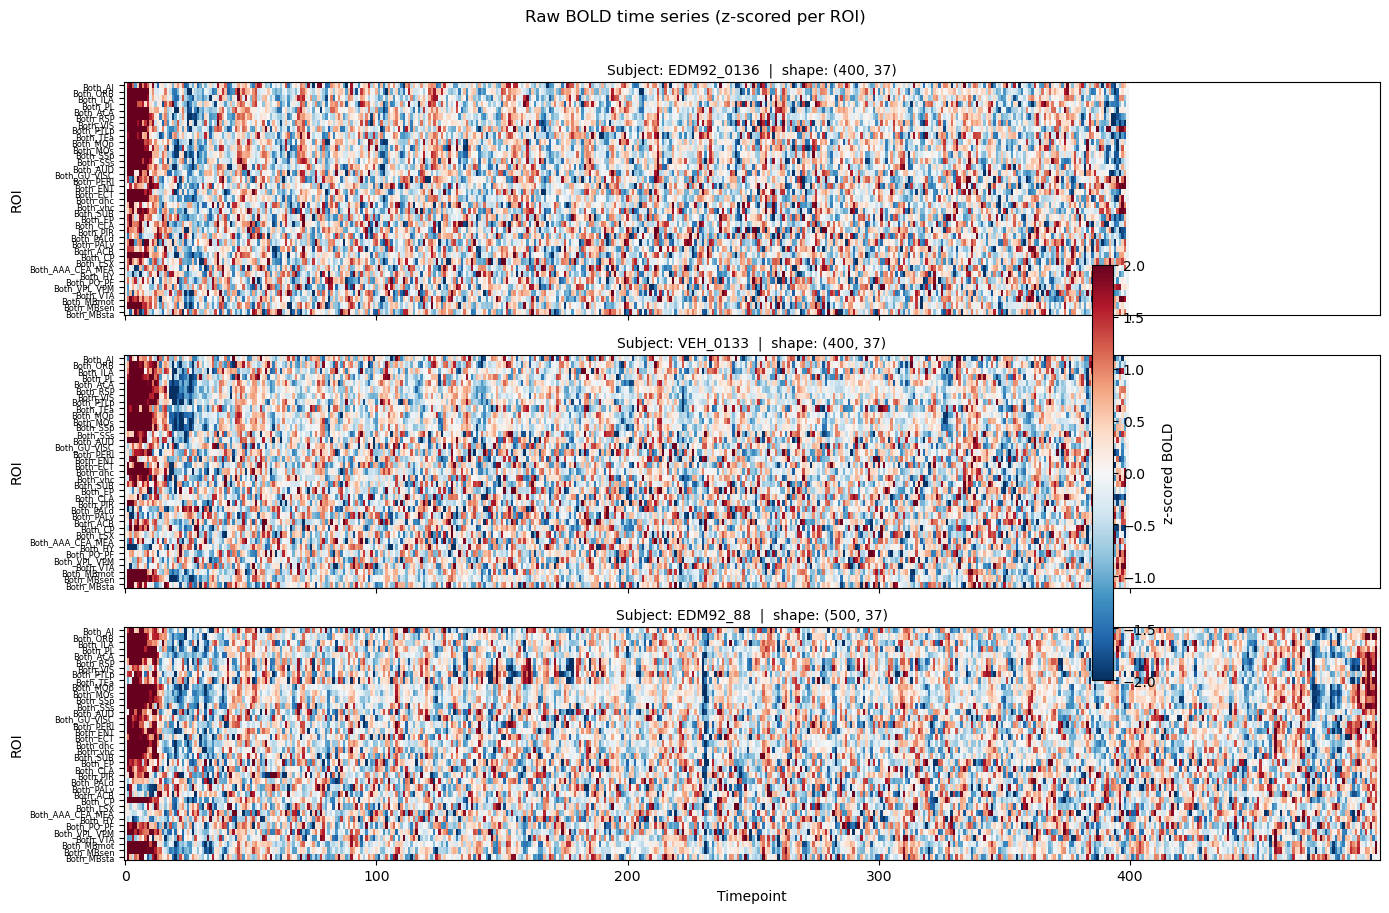

In [2]:
def load_ts(path):
    mat = loadmat(path)
    ts = mat["tc"]
    if ts.shape[0] < ts.shape[1]:
        ts = ts.T
    # z-score each ROI for visualization
    ts_z = (ts - ts.mean(axis=0)) / ts.std(axis=0)
    return ts, ts_z

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for ax, (name, path) in zip(axes, SUBJECTS.items()):
    ts, ts_z = load_ts(path)
    im = ax.imshow(
        ts_z.T,
        aspect="auto",
        cmap="RdBu_r",
        vmin=-2, vmax=2,
        interpolation="nearest",
    )
    ax.set_yticks(range(len(ROI_NAMES)))
    ax.set_yticklabels(ROI_NAMES, fontsize=6)
    ax.set_title(f"Subject: {name}  |  shape: {ts.shape}", fontsize=10)
    ax.set_ylabel("ROI")

axes[-1].set_xlabel("Timepoint")
fig.colorbar(im, ax=axes, label="z-scored BOLD", shrink=0.6)
fig.suptitle("Raw BOLD time series (z-scored per ROI)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 2. dFC stream — sliding window Pearson correlation

For each window of size `w`, we compute the Pearson correlation matrix across all 37 ROIs.
Sliding the window by `lag=1` TR produces a stream of FC matrices.

We show:
- The full dFC stream as a heatmap (upper triangle vectorized)
- Three example FC snapshots at different time points

We use `window=40` (medium) for this illustration.

In [ ]:
DEMO_WINDOW = 40
DEMO_SUBJECT = "EDM92_0136"

ts, _ = load_ts(SUBJECTS[DEMO_SUBJECT])

# Build 2D and 3D dFC streams
dfc_2d = ts2dfc_stream(ts, window_size=DEMO_WINDOW, lag=LAG, format_data="2D")
dfc_3d = ts2dfc_stream(ts, window_size=DEMO_WINDOW, lag=LAG, format_data="3D")

n_pairs, n_frames = dfc_2d.shape
print(f"dFC stream shape (2D): {dfc_2d.shape}  → ({n_pairs} pairs × {n_frames} frames)")
print(f"dFC stream shape (3D): {dfc_3d.shape}")

# Choose 3 snapshot timepoints
t_snaps = [0, n_frames // 2, n_frames - 1]

fig = plt.figure(figsize=(16, 7))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.4, wspace=0.35)

# --- dFC stream heatmap ---
ax_stream = fig.add_subplot(gs[:, 0])
ax_stream.imshow(
    dfc_2d,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-1, vmax=1,
    interpolation="nearest",
)
ax_stream.set_xlabel("Frame")
ax_stream.set_ylabel("FC pair (upper triangle)")
ax_stream.set_title(f"dFC stream\nwindow={DEMO_WINDOW}", fontsize=10)
for t in t_snaps:
    ax_stream.axvline(t, color="gold", lw=1.2, ls="--")

# --- FC snapshots ---
snap_axes = [fig.add_subplot(gs[r, c]) for r, c in [(0,1),(0,2),(0,3),(1,1),(1,2),(1,3)]]
for i, t in enumerate(t_snaps):
    ax = snap_axes[i]
    fc = dfc_3d[:, :, t]
    np.fill_diagonal(fc, 0)
    im = ax.imshow(fc, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title(f"FC at frame {t}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, shrink=0.7)

# --- Mean FC ---
ax_mean = snap_axes[3]
mean_fc = dfc_3d.mean(axis=2)
np.fill_diagonal(mean_fc, 0)
im2 = ax_mean.imshow(mean_fc, cmap="RdBu_r", vmin=-1, vmax=1)
ax_mean.set_title("Mean FC", fontsize=9)
ax_mean.set_xticks([]); ax_mean.set_yticks([])
fig.colorbar(im2, ax=ax_mean, shrink=0.7)

# --- FC std (variability) ---
ax_std = snap_axes[4]
std_fc = dfc_3d.std(axis=2)
np.fill_diagonal(std_fc, 0)
im3 = ax_std.imshow(std_fc, cmap="hot_r", vmin=0)
ax_std.set_title("FC std (variability)", fontsize=9)
ax_std.set_xticks([]); ax_std.set_yticks([])
fig.colorbar(im3, ax=ax_std, shrink=0.7)

snap_axes[5].axis("off")

fig.suptitle(f"dFC stream — Subject {DEMO_SUBJECT} | window={DEMO_WINDOW}", fontsize=12)
plt.show()

## 3. Global dFC speed

Speed at frame `t` = `1 - corr(FC[t], FC[t + time_window])`

High speed → the whole-brain connectivity pattern changed a lot between two windows.
Low speed → connectivity is stable.

We compare all 3 subjects across the 3 window sizes.

In [ ]:
fig, axes = plt.subplots(len(WINDOW_SIZES), 1, figsize=(14, 9), sharex=False)

for ax, w in zip(axes, WINDOW_SIZES):
    for name, path in SUBJECTS.items():
        speed_mean, _, speed_vals = compute_subject_global_speed(
            path, window_size=w, lag=LAG, vstep=VSTEP, tau_range=TAU_RANGE
        )
        ax.plot(
            speed_vals,
            color=COLORS[name],
            lw=1.0,
            alpha=0.85,
            label=f"{name} (μ={speed_mean:.3f})",
        )
    ax.set_title(f"Window = {w} TRs", fontsize=10)
    ax.set_ylabel("Speed (1 - corr)")
    ax.set_ylim(0, 2)
    ax.axhline(1.0, color="gray", lw=0.5, ls=":")
    ax.legend(fontsize=8, loc="upper right")

axes[-1].set_xlabel("Frame")
fig.suptitle("Global dFC speed timecourse — 3 subjects × 3 window sizes", fontsize=12)
plt.tight_layout()
plt.show()

### 3b. Speed distribution — effect of window size

Longer windows → smoother FC → lower apparent speed.
This is a key methodological point: the window size directly shapes the speed distribution.

In [ ]:
fig, axes = plt.subplots(1, len(SUBJECTS), figsize=(14, 4), sharey=True)

for ax, (name, path) in zip(axes, SUBJECTS.items()):
    for w, ls in zip(WINDOW_SIZES, ["-", "--", ":"]):
        _, _, speed_vals = compute_subject_global_speed(
            path, window_size=w, lag=LAG, vstep=VSTEP, tau_range=TAU_RANGE
        )
        sns.kdeplot(
            speed_vals,
            ax=ax,
            color=COLORS[name],
            ls=ls,
            lw=1.8,
            label=f"w={w}",
        )
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Speed")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Density")
fig.suptitle("Speed distribution shifts with window size", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Nodal dFC speed

Instead of using the full FC matrix, we compute speed **per ROI**:
for region `i`, we use only its row in the FC matrix (its connectivity profile with all other regions).

This reveals **which regions drive the global speed** and which are stable hubs.

We use `window=40` for this illustration.

In [ ]:
DEMO_WINDOW = 40

nodal_speeds = {}
for name, path in SUBJECTS.items():
    pct, pgrid, rois, raw, ts_shape, dfc_shape = compute_subject_nodal_speed(
        path, window_size=DEMO_WINDOW, lag=LAG, vstep=VSTEP, tau_range=TAU_RANGE
    )
    # raw shape: (n_rois, n_tau, n_frames) → mean over tau and frames
    nodal_speeds[name] = raw.mean(axis=(1, 2))  # (37,)
    print(f"{name}: nodal speed shape {raw.shape} → mean per ROI shape {nodal_speeds[name].shape}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Bar plot: mean nodal speed per ROI ---
ax = axes[0]
x = np.arange(len(ROI_NAMES))
width = 0.28
for i, (name, speeds) in enumerate(nodal_speeds.items()):
    ax.bar(x + i * width, speeds, width=width, color=COLORS[name], alpha=0.8, label=name)

ax.set_xticks(x + width)
ax.set_xticklabels(ROI_NAMES, rotation=90, fontsize=7)
ax.set_ylabel("Mean nodal speed")
ax.set_title(f"Nodal speed per ROI (window={DEMO_WINDOW})")
ax.legend(fontsize=8)

# --- Heatmap: ROIs × subjects ---
ax2 = axes[1]
mat = np.stack([nodal_speeds[n] for n in SUBJECTS], axis=1)  # (37, 3)
im  = ax2.imshow(mat, aspect="auto", cmap="YlOrRd")
ax2.set_yticks(range(len(ROI_NAMES)))
ax2.set_yticklabels(ROI_NAMES, fontsize=7)
ax2.set_xticks(range(len(SUBJECTS)))
ax2.set_xticklabels(list(SUBJECTS.keys()), rotation=20, fontsize=9)
ax2.set_title("Nodal speed heatmap (ROIs × subjects)")
fig.colorbar(im, ax=ax2, label="Mean speed", shrink=0.8)

fig.suptitle("Nodal dFC speed", fontsize=12)
plt.tight_layout()
plt.show()

## 5. Window-size sensitivity

We sweep windows 5–100 for all 3 subjects and plot:
- Mean global speed as a function of window size
- This is the key curve that motivates the multi-scale analysis in the full batch

**EDM92_88** should show a steeper or more variable curve — that's what makes it interesting.

In [ ]:
WINDOW_SWEEP = list(range(5, 101, 5))  # every 5 TRs for speed

speed_curves = {name: [] for name in SUBJECTS}

for name, path in SUBJECTS.items():
    for w in WINDOW_SWEEP:
        mean_speed, _, _ = compute_subject_global_speed(
            path, window_size=w, lag=LAG, vstep=VSTEP, tau_range=TAU_RANGE
        )
        speed_curves[name].append(mean_speed)
    print(f"{name} done")

fig, ax = plt.subplots(figsize=(10, 5))

for name, curve in speed_curves.items():
    ax.plot(WINDOW_SWEEP, curve, color=COLORS[name], lw=2, marker="o", ms=4, label=name)

ax.set_xlabel("Window size (TRs)")
ax.set_ylabel("Mean global speed")
ax.set_title("Speed vs window size — 3 subjects")
ax.legend(fontsize=9)
ax.axvspan(5, 31, alpha=0.05, color="blue", label="short")
ax.axvspan(32, 62, alpha=0.05, color="green", label="mid")
ax.axvspan(63, 100, alpha=0.05, color="red", label="long")
plt.tight_layout()
plt.show()

## 6. Group comparison preview — EDM92 vs VEH

Using the full batch outputs already computed on funsystem.
We load the global speed CSV and compare group distributions across window bins.

In [ ]:
df = pd.read_csv(PATH_OUT / "global_speed_mean_all_subjects_windows_5_100.csv")

# Add group label
df["group"] = df["subject"].apply(lambda s: "EDM92" if "EDM92" in s else "VEH")

# Add window bin
df["window_bin"] = pd.cut(
    df["window"],
    bins=[0, 31, 62, 100],
    labels=["short (5-31)", "mid (32-62)", "long (63-100)"]
)

print(df.groupby(["group", "window_bin"])["speed"].describe().round(3))

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

group_colors = {"EDM92": "#2196F3", "VEH": "#FF9800"}

for ax, (wbin, gdf) in zip(axes, df.groupby("window_bin", observed=True)):
    # Subject-level means per group
    subj_means = gdf.groupby(["subject", "group"])["speed"].mean().reset_index()

    sns.boxplot(
        data=subj_means,
        x="group", y="speed",
        palette=group_colors,
        width=0.4,
        ax=ax,
        fliersize=0,
    )
    sns.stripplot(
        data=subj_means,
        x="group", y="speed",
        palette=group_colors,
        size=6, jitter=0.15, alpha=0.7,
        ax=ax,
    )
    ax.set_title(f"{wbin}", fontsize=10)
    ax.set_xlabel("")

axes[0].set_ylabel("Mean global speed")
fig.suptitle("EDM92 vs VEH — global speed by window bin\n(preview, no statistics)", fontsize=12)
plt.tight_layout()
plt.show()

## Summary

| Stage | What we computed | Key observation |
|---|---|---|
| BOLD | 400 × 37 time series | Visually heterogeneous across ROIs and subjects |
| dFC stream | sliding-window Pearson | FC reorganizes continuously; variability differs by region |
| Global speed | 1 - corr(FC[t], FC[t+w]) | Decreases with window size; EDM92_88 shows higher variability |
| Nodal speed | per-ROI connectivity fingerprint speed | Some ROIs systematically faster than others |
| Window sweep | speed vs w=5..100 | Motivates multi-scale analysis across all 96 windows |
| Group preview | EDM92 vs VEH | Visible trends warrant formal statistical testing (Phase 4) |

**Next:** Phase 3 — numerical comparison of the old vs new speed computation, and timing benchmarks.